# QRコードのデコード手順：データに破損がない場合(Happy Path)

<a href="https://github.com/Tsukumo-999/qr-code-from-scratch/blob/master/Step2/Hello_Decode_happy_path.ipynb" target="_parent">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

第7回記事「[QRコードをデコードする（Happy Path）【QRコードを解読する 第7回】](https://tukumolog.com/qr-code-decode-07-hello-recovery/)」で行った、QRコードが破損なく検出できた場合のデコード手順です。

## 1.画像から2次元配列（matrix）への復元
カメラで綺麗に正面から撮影され、二値化（白黒ハッキリ）されたと仮定し、
前回の出力画像から 25x25 の 0と1の配列 を取得します。

1.1 検出器の設定

対象とするQR画像


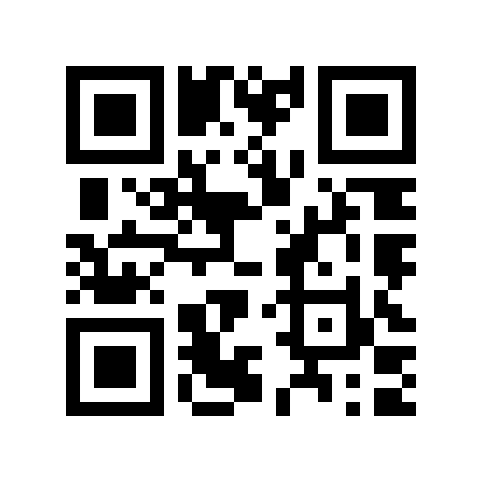

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# エンコード編で出力した画像パス
IMG_PATH = 'qr_hello.png'

# バージョン2のグリッドサイズ
GRID_SIZE = 25 
TARGET_SIDE = 500  # 補正後の画像サイズ(500x500px)に拡大して精度を上げる
CELL_SIZE = TARGET_SIDE / GRID_SIZE  # 1マスあたり20px

## 対象とするQRコードの確認
print("対象とするQR画像")
target_img = cv2.imread(IMG_PATH)
plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(target_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


【補足】<br>
 実際のQRコードリーダーでは、画像からファインダパタン（3つの大きな目印）を検出し、<br>
 その比率や距離から「1マスのピクセル幅」を算出します。<br>
 また、QRコードはバージョン1(21x21)から始まり、4マスずつ増える「奇数サイズ」の規格です。<br>
 タイミングパターン（6行/列目にある白黒の縞模様）の数を数えたりして、<br>
 21, 25, 29... のどのサイズに該当するかを動的に判定するアルゴリズムが組み込まれています。<br>
 今回は理論の解説に集中するため、サイズは既知の「25」として進めます。<br>

### 1.2 画像処理でビットマップを得る
この部分は、様々な手法があり、ロバストな１D探索をpythonで実装するのは計算速度的に健康的とは言えないので、<br>
きれいな画像（あえて破損させたものもふくむが、ボケていない）がえられたという前提で検出させている。<br>
簡易検出のプログラムです。<br>

In [17]:
#$# 第2セル：高精度検出パイプラインの定義（X・Y反転バグ修正版）

def get_finder_patterns(thresh):
    """入れ子構造(階層)からファインダパタンの中心座標を3つ探し出す"""
    contours, hierarchy = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    centers = []
    
    if hierarchy is None: return centers
    
    for i in range(len(contours)):
        child_idx = hierarchy[0][i][2]
        if child_idx != -1:
            grandchild_idx = hierarchy[0][child_idx][2]
            if grandchild_idx != -1:
                # 子、孫を持つ輪郭（黒枠→白枠→黒中心）を発見
                c = contours[i]
                if cv2.contourArea(c) < 50: continue
                
                rect = cv2.minAreaRect(c)
                w, h = rect[1]
                if w == 0 or h == 0: continue
                
                # ほぼ正方形であることを確認
                aspect_ratio = max(w, h) / min(w, h)
                if aspect_ratio < 1.5:
                    M = cv2.moments(c)
                    if M["m00"] != 0:
                        cx = M["m10"] / M["m00"]
                        cy = M["m01"] / M["m00"]
                        # 近接した重複検出を防ぐ
                        if not any(np.hypot(cx - ex, cy - ey) < 15 for ex, ey in centers):
                            centers.append(np.array([cx, cy], dtype=np.float32))
    return centers

def sort_finder_patterns(centers):
    """3つの点の距離から、左上(TL)、右上(TR)、左下(BL)を判定する"""
    pts = np.array(centers)
    # 3点間の距離を計算
    d01 = np.linalg.norm(pts[0] - pts[1])
    d12 = np.linalg.norm(pts[1] - pts[2])
    d02 = np.linalg.norm(pts[0] - pts[2])
    
    # 最も長い距離（斜辺）の向かいにある点が「左上(TL)の直角部分」
    max_d = max(d01, d12, d02)
    if max_d == d01:   tl_idx, tr_idx, bl_idx = 2, 0, 1
    elif max_d == d12: tl_idx, tr_idx, bl_idx = 0, 1, 2
    else:              tl_idx, tr_idx, bl_idx = 1, 0, 2
    
    TL = pts[tl_idx]
    
    # 【修正箇所】外積を使ってTRとBLを区別する (符号を > 0 に修正)
    if np.cross(pts[tr_idx] - TL, pts[bl_idx] - TL) > 0:
        TR, BL = pts[tr_idx], pts[bl_idx]
    else:
        TR, BL = pts[bl_idx], pts[tr_idx]
        
    return TL, TR, BL

def process_qr_image(img_path):
    print("===== 2次元コード解析パイプライン 開始 =====")
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError("画像が読み込めません。")
        
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # 二値化（適応的閾値処理で影などのノイズに強くする）
    thresh = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY_INV, 21, 5)
    
    # 1. ファインダパタンの検出
    centers = get_finder_patterns(thresh)
    if len(centers) < 3:
        raise ValueError(f"ファインダパタンが3つ見つかりません。(検出数: {len(centers)})")
        
    TL, TR, BL = sort_finder_patterns(centers[:3])
    
    # 4つ目の角（右下）を推測
    estimated_BR = TR + BL - TL
    
    # デバッグ描画用（元画像に検出した角をプロット）
    debug_corners = img.copy()
    cv2.circle(debug_corners, tuple(map(int, TL)), 8, (0, 0, 255), -1) # 赤: TL
    cv2.circle(debug_corners, tuple(map(int, TR)), 8, (0, 255, 0), -1) # 緑: TR
    cv2.circle(debug_corners, tuple(map(int, BL)), 8, (255, 0, 0), -1) # 青: BL
    cv2.polylines(debug_corners, [np.int32([TL, TR, estimated_BR, BL])], True, (0, 255, 255), 2)
    

    # 2. 透視変換による正面補正
    # ファインダパタンの中心は、端から 3.5マスの位置にある
    offset = 3.5 * CELL_SIZE
    far_offset = (GRID_SIZE - 3.5) * CELL_SIZE
    
    src_pts = np.float32([TL, TR, BL, estimated_BR])
    dst_pts = np.float32([
        [offset, offset],          # 左上
        [far_offset, offset],      # 右上
        [offset, far_offset],      # 左下
        [far_offset, far_offset]   # 推測された右下
    ])
    
    M = cv2.getPerspectiveTransform(src_pts, dst_pts)
    warped = cv2.warpPerspective(img, M, (TARGET_SIDE, TARGET_SIDE))
    
    # 3. マスの中心からビットをサンプリング
    warped_gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
    _, warped_thresh = cv2.threshold(warped_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    
    bit_map = np.zeros((GRID_SIZE, GRID_SIZE), dtype=int)
    debug_samples = warped.copy()
    
    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            cx = int((col + 0.5) * CELL_SIZE)
            cy = int((row + 0.5) * CELL_SIZE)
            
            # 白=0, 黒=1 として格納
            if warped_thresh[cy, cx] > 128:
                bit_map[row, col] = 0
                cv2.circle(debug_samples, (cx, cy), 3, (0, 0, 255), -1) # 赤点: 白検出
            else:
                bit_map[row, col] = 1
                cv2.circle(debug_samples, (cx, cy), 3, (255, 0, 0), -1) # 青点: 黒検出



    # 可視化
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(cv2.cvtColor(debug_corners, cv2.COLOR_BGR2RGB))
    axes[0].set_title("STEP1: Finder Patterns Detected")
    axes[0].axis('off')
    
    axes[1].imshow(cv2.cvtColor(debug_samples, cv2.COLOR_BGR2RGB))
    axes[1].set_title("STEP2: Warped & Sampled (Red=0, Blue=1)")
    axes[1].axis('off')
    plt.show()

    return bit_map

print("検出プログラムのロードが完了しました。")

検出プログラムのロードが完了しました。


### 1.3 実行とビットマップの出力

===== 2次元コード解析パイプライン 開始 =====


C:\Users\akiak\AppData\Local\Temp\ipykernel_12364\1785322232.py:52: DeprecationWarning: Arrays of 2-dimensional vectors are deprecated. Use arrays of 3-dimensional vectors instead. (deprecated in NumPy 2.0)
  if np.cross(pts[tr_idx] - TL, pts[bl_idx] - TL) > 0:


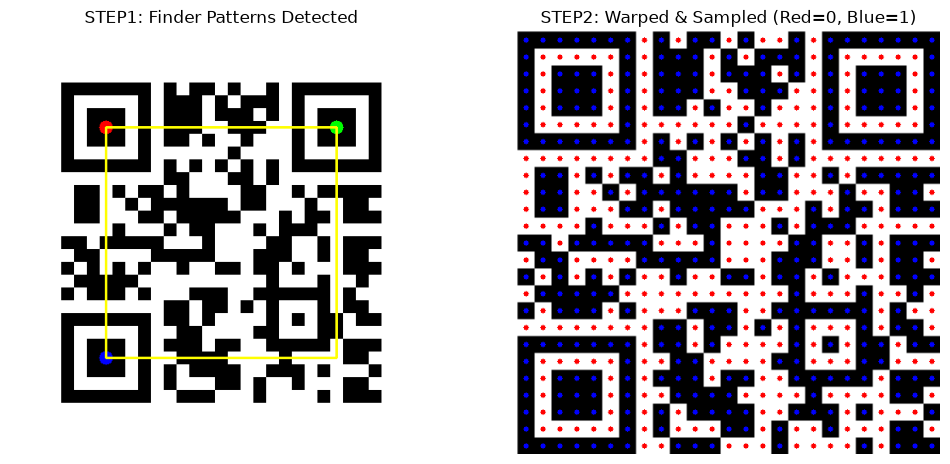


【抽出された2次元配列 (0:白, 1:黒)】
[1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1]
[1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1]
[1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1]
[1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1]
[1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1]
[1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1]
[1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1]
[0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
[0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1]
[0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0]
[0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1]
[0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0]
[1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1,

In [18]:
# 実際に画像を読み込み、抽出された配列を変数に格納します。

qr_matrix = process_qr_image(IMG_PATH)

print("\n【抽出された2次元配列 (0:白, 1:黒)】")
for row in qr_matrix:
    print([int(b) for b in row])

# この qr_matrix を用いて、次のステップ（フォーマット解読・デコード）へ進みます。

## 2. マスクとデータ形式情報を取得する。
QRコードでは、ファインダパタンの周りの決まった位置にマスクやデータ形式の情報が入っています。<br>
これを読み取ることで、マスクパタンの情報などをデコーダ側で取得します<br>
詳しくは：[QRコードの作り方を徹底解説｜"HELLO"を例にエンコーダをゼロから実装する【QRコードを解読する 第6回】](https://tukumolog.com/qr-code-encode-tutorial/)<br>

### 2.1 フォーマット情報の抽出
QRコードの規格では、汚れや破れに備えて「全く同じフォーマット情報」が2箇所に記録されています。
両方を読み取って比較し、堅牢な検出を行います。

In [19]:
print("【2.1 フォーマット情報の抽出】")

# 1箇所目: 左上ファインダパタンの周り
format_coords_1 = [
    (0,8), (1,8), (2,8), (3,8), (4,8), (5,8), (7,8), (8,8), (8,7), (8,5), (8,4), (8,3), (8,2), (8,1), (8,0)
]
# 2箇所目: 右上および左下ファインダパタンの隣
format_coords_2 = [
    (8,24), (8,23), (8,22), (8,21), (8,20), (8,19), (8,18), (17,8), (18,8), (19,8), (20,8), (21,8), (22,8), (23,8), (24,8)
]

def read_format_bits(coords, matrix):
    """指定された座標リストから15ビットの整数を読み取る"""
    fmt_code = 0
    for i, (x, y) in enumerate(coords):
        bit = matrix[y][x]
        fmt_code |= (bit << (14 - i))  # 上位ビットから順にシフトして格納
    return fmt_code

fmt_code_1 = read_format_bits(format_coords_1, qr_matrix)
fmt_code_2 = read_format_bits(format_coords_2, qr_matrix)

print(f"抽出したフォーマット情報1: {format(fmt_code_1, '015b')}")
print(f"抽出したフォーマット情報2: {format(fmt_code_2, '015b')}")

if fmt_code_1 == fmt_code_2:
    print("→ 2箇所の情報が完全に一致しました。欠損はありません。")
    final_fmt_code = fmt_code_1
else:
    # ブログ解説用：実際のデコーダはここでBCH符号の計算（誤り訂正）を行い、正しい方を採用します。
    print("→ 不一致が発生しています。今回は簡易的に情報1を採用します。")
    final_fmt_code = fmt_code_1

【2.1 フォーマット情報の抽出】
抽出したフォーマット情報1: 011010101011111
抽出したフォーマット情報2: 011010101011111
→ 2箇所の情報が完全に一致しました。欠損はありません。


### 2.2 フォーマット情報の復元と解析
 読み取った15ビットは、読み取り精度を上げるためのマスク（101010000010010）が掛かっています。<br>
 同じ値をもう一度XOR（排他的論理和）することで、元の情報が復元されます。<br>

In [32]:
print("【2.2 フォーマットの復元とマスクパターンの認識】")

# 1. XOR演算によるマスク解除
unmasked_fmt_code = final_fmt_code ^ 0b101010000010010

# 2. 下位10ビット（BCHエラー訂正符号）を切り捨てて、上位5ビット（データ）を取り出す
format_data = unmasked_fmt_code >> 10

# 3. 5ビットのうち、上位2ビットが「誤り訂正レベル」、下位3ビットが「マスクパターン」
ec_level_bits = format_data >> 3
mask_pattern_bits = format_data & 0b111

# 誤り訂正レベルの対応表 (01:L, 00:M, 11:Q, 10:H)
ec_level_map = {1: 'L', 0: 'M', 3: 'Q', 2: 'H'}
ec_level = ec_level_map.get(ec_level_bits, 'Unknown')

print(f"マスク解除後の5ビット: {format(format_data, '05b')}")
print(f"→ 誤り訂正レベル: {ec_level}")
print(f"→ マスクパターン番号: 00{mask_pattern_bits} (2進数: {format(mask_pattern_bits, '03b')})")

# 以降の処理のために、マスクパターンの条件式を定義しておきます
def get_mask_condition(pattern_num):
    # x(列), y(行) として定義
    if pattern_num == 0: return lambda x, y: (x + y) % 2 == 0
    if pattern_num == 1: return lambda x, y: y % 2 == 0
    if pattern_num == 2: return lambda x, y: x % 3 == 0
    if pattern_num == 3: return lambda x, y: (x + y) % 3 == 0
    if pattern_num == 4: return lambda x, y: (y // 2 + x // 3) % 2 == 0
    if pattern_num == 5: return lambda x, y: ((x * y) % 2) + ((x * y) % 3) == 0
    if pattern_num == 6: return lambda x, y: (((x * y) % 2) + ((x * y) % 3)) % 2 == 0
    if pattern_num == 7: return lambda x, y: (((x + y) % 2) + ((x * y) % 3)) % 2 == 0
    return lambda x, y: False

# 前半の処理で取得した mask_pattern_bits を渡す
mask_condition = get_mask_condition(mask_pattern_bits)

【2.2 フォーマットの復元とマスクパターンの認識】
マスク解除後の5ビット: 11000
→ 誤り訂正レベル: Q
→ マスクパターン番号: 000 (2進数: 000)


読み取ったフォーマット情報は以下のようになっているはずです。<br>
<br>
【2.2 フォーマットの復元とマスクパターンの認識】<br>
マスク解除後の5ビット: 11000<br>
→ 誤り訂正レベル: Q<br>
→ マスクパターン番号: 000 (2進数: 000)<br>
<br>
誤り訂正レベルはQで マスクパタンは(000)、市松模様であることがわかります。<br>
<img src="./../docments/QR-mask-pattern.png"></img><br>

引用元：[JIS 0510](https://kikakurui.com/x0/X0510-2018-01.html). p50 ,図21−1型シンボルに対するマスクパターンより引用


### 2.3 データ領域のマスク解除
マスクパターンが判明したので、エンコード時と同じ条件で配列全体をXORし、データの白黒反転を元に戻します。

In [33]:
print("【2.3 データ領域のマスク解除】")

def is_reserved(x, y):
    """エンコード時と同じ、固定パターン・予約領域の判定"""
    if (0 <= x <= 8 and 0 <= y <= 8): return True
    if (GRID_SIZE - 8 <= x < GRID_SIZE and 0 <= y <= 8): return True
    if (0 <= x <= 8 and GRID_SIZE - 8 <= y < GRID_SIZE): return True
    if x == 6 or y == 6: return True
    if 16 <= x <= 20 and 16 <= y <= 20: return True
    return False

# 元の配列を破壊しないようにコピーを作成
unmasked_matrix = [row[:] for row in qr_matrix]

# データ領域のみを対象にマスクを解除（反転）
for y in range(GRID_SIZE):
    for x in range(GRID_SIZE):
        if not is_reserved(x, y):
            if mask_condition(x, y):
                unmasked_matrix[y][x] ^= 1  # 1なら0、0なら1に反転

print("マスクの解除が完了しました。これで純粋なデータが盤面に現れました。")

for row in unmasked_matrix:
    print(''.join(map(str, row)))

【2.3 データ領域のマスク解除】
マスクの解除が完了しました。これで純粋なデータが盤面に現れました。
1111111010011110001111111
1000001010111110101000001
1011101011000100001011101
1011101010110010001011101
1011101011111000101011101
1000001001010001001000001
1111111010101010101111111
0000000010010011100000000
0110101101101001101011111
0011000010101110010001100
1100101111010110111100010
0101110111100100001001010
0111011110111010011000010
0011010010100100100111100
0000001011100111000010010
0010100101010101110111000
0001001010010011111110001
0000000010001111100011100
1111111011111010101011110
1000001000110100100010010
1011101011000110111110010
1011101000101101000101100
1011101010010110010000100
1000001011011000011101100
1111111001011011101000010


### 2.4 ジグザグスキャンによる1次元ビット列の抽出
右下からスタートし、タイミングパターンや予約領域を避けながら、2列ずつ上・下へと回収していきます。

In [34]:
print("【2.4 ジグザグスキャンで1次元に読み出す】")

extracted_bits = []
x = GRID_SIZE - 1
upward = True

while x > 0:
    if x == 6: x -= 1 # タイミングパターンの列（インデックス6）をスキップ
    
    y_range = range(GRID_SIZE - 1, -1, -1) if upward else range(GRID_SIZE)
    
    for y in y_range:
        for dx in (0, -1):
            cx = x + dx
            if not is_reserved(cx, y):
                extracted_bits.append(unmasked_matrix[y][cx])
                
    upward = not upward
    x -= 2

print(f"回収したビット数: {len(extracted_bits)} ビット")
print(f"(※バージョン2の規格上、データ領域は 359マス なので 359ビット になるのが正解です)")

# ビットのリストを文字列に変換して確認
bit_string = "".join(str(b) for b in extracted_bits)

print("\n▼ 抽出された1次元ビットストリーム ▼")
# 見やすいように8ビット（1バイト）ごとに区切って表示
formatted_bit_string = " ".join([bit_string[i:i+8] for i in range(0, len(bit_string), 8)])
print(formatted_bit_string)

【2.4 ジグザグスキャンで1次元に読み出す】
回収したビット数: 359 ビット
(※バージョン2の規格上、データ領域は 359マス なので 359ビット になるのが正解です)

▼ 抽出された1次元ビットストリーム ▼
01000000 01010100 10000100 01010100 11000100 11000100 11110000 11101100 00010001 11101100 00010001 11101100 00010001 11101100 00010001 11101100 00010001 11101100 00010001 11101100 00010001 11101100 11101101 11001110 11100101 11101100 00111100 10100001 10001101 00101110 10011110 01001101 10100111 00111101 01101000 01110011 00001011 00110101 11111100 00111101 00001001 00100111 11000110 01110100 0000000


## 3.リードソロモン符号での検証と復元

### 3.1 1次元ビットストリームを「バイト（コード語）」に変換する
回収したビット列を8ビットずつ区切り、計算用の整数配列（コード語）に変換します。

In [35]:
print("【3.1 ビット列からコード語（バイト）への変換】")

# バージョン2・誤り訂正レベルQの総容量は 44バイト（352ビット）です。
# 盤面から回収した359ビットのうち、末尾の7ビットは規格上の「余り（残余ビット）」なので無視します。
TOTAL_CODEWORDS = 44
EC_CODEWORDS = 22
DATA_CODEWORDS = TOTAL_CODEWORDS - EC_CODEWORDS

received_codewords = []
for i in range(0, TOTAL_CODEWORDS * 8, 8):
    byte_str = bit_string[i:i+8]
    received_codewords.append(int(byte_str, 2))

# データ部とエラー訂正部（パリティ）に分割
data_part = received_codewords[:DATA_CODEWORDS]
ec_part = received_codewords[DATA_CODEWORDS:]

print(f"▼ データ部 ({len(data_part)}バイト) ▼\n{data_part}\n")
print(f"▼ 誤り訂正部 ({len(ec_part)}バイト) ▼\n{ec_part}\n")

【3.1 ビット列からコード語（バイト）への変換】
▼ データ部 (22バイト) ▼
[64, 84, 132, 84, 196, 196, 240, 236, 17, 236, 17, 236, 17, 236, 17, 236, 17, 236, 17, 236, 17, 236]

▼ 誤り訂正部 (22バイト) ▼
[237, 206, 229, 236, 60, 161, 141, 46, 158, 77, 167, 61, 104, 115, 11, 53, 252, 61, 9, 39, 198, 116]



### 3.2 ガロア体 GF(2^8) の演算準備
多項式の計算を行うため、エンコード編でも使用したガロア体のテーブルと掛け算関数を準備します。


In [36]:

exp_table = [0] * 256
log_table = [0] * 256
v = 1
for i in range(255):
    exp_table[i] = v
    log_table[v] = i
    v <<= 1
    if v & 0x100: v ^= 0x11D
exp_table[255] = exp_table[0]

def gf_mul(x, y):
    """ガロア体上の掛け算"""
    if x == 0 or y == 0: return 0
    return exp_table[(log_table[x] + log_table[y]) % 255]

print("ガロア体 GF(2^8) の演算テーブルをロードしました。")

ガロア体 GF(2^8) の演算テーブルをロードしました。


### 3.3 シンドローム（エラーの兆候）の計算
受信したデータをひとつの巨大な多項式 R(x) とみなし、
そこに α^0, α^1, ..., α^21 を代入して、結果が 0 になるかを確認します。

In [37]:
print("【3.3 シンドロームの計算によるデータ検証】")

syndromes = []

# 誤り訂正コードの数（22個）だけシンドローム S_0 〜 S_21 を計算します
for i in range(EC_CODEWORDS):
    alpha_i = exp_table[i]  # 代入する値 (α^i)
    
    # ホーナー法（Horner's method：高次の掛け算と加算を、ネストに分解して効率的に計算する方法です。）を用いて多項式 R(α^i) を効率的に計算
    # ホーナー法についてはこちらで解説 https://tukumolog.com/polynomial-optimization-horner-method/
    syndrome = 0
    for coef in received_codewords:
        syndrome = coef ^ gf_mul(syndrome, alpha_i) # 足し算はXOR
        
    syndromes.append(syndrome)

print(f"▼ 計算されたシンドローム (計{len(syndromes)}個) ▼")
print(syndromes)

# 検証結果の判定
if all(s == 0 for s in syndromes):
    print("\n✅ 【検証成功】すべてのシンドロームが 0 です。データに一切の破損はありません！")
    print("   このままデータ部をデコードして文字列を復元できます。")
else:
    print("\n❌ 【エラー検出】0ではないシンドロームが存在します。データが破損しています。")
    print("   ※今回は発生しませんが、もし画像に汚れや欠損があった場合、ここに 0 以外の数値が現れます。")
    print("   ※この「0ではないシンドロームの配列」こそが、エラーの場所と値を特定する「バーレカンプ・マッシー法」などの修復アルゴリズムへと渡される重要な手がかりになります。")

【3.3 シンドロームの計算によるデータ検証】
▼ 計算されたシンドローム (計22個) ▼
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

✅ 【検証成功】すべてのシンドロームが 0 です。データに一切の破損はありません！
   このままデータ部をデコードして文字列を復元できます。


## 4. データの解析と復元

今回は破損が一切ないため、ヘッダーとデータコード語の部分をそのまま復元するだけで読み取ることができます。

### 4.1 codewordの確認
確認すると、データ部の後部は236と17による埋め草部分であることがわかります

In [41]:
# データ部とエラー訂正部（パリティ）を確認
# data_part = received_codewords[:DATA_CODEWORDS]
# ec_part = received_codewords[DATA_CODEWORDS:]

print(f"▼ データ部 ({len(data_part)}バイト) ▼\n{data_part}\n")
print(f"▼ 誤り訂正部 ({len(ec_part)}バイト) ▼\n{ec_part}\n")

print(f"▼ 生データ▼\n{bit_string}")

▼ データ部 (22バイト) ▼
[64, 84, 132, 84, 196, 196, 240, 236, 17, 236, 17, 236, 17, 236, 17, 236, 17, 236, 17, 236, 17, 236]

▼ 誤り訂正部 (22バイト) ▼
[237, 206, 229, 236, 60, 161, 141, 46, 158, 77, 167, 61, 104, 115, 11, 53, 252, 61, 9, 39, 198, 116]

▼ 生データ▼
01000000010101001000010001010100110001001100010011110000111011000001000111101100000100011110110000010001111011000001000111101100000100011110110000010001111011000001000111101100111011011100111011100101111011000011110010100001100011010010111010011110010011011010011100111101011010000111001100001011001101011111110000111101000010010010011111000110011101000000000


### 4.2 データを読み取り復元する

ヘッダー16bit ：先頭4bitはモード、以降の12bitで文字数

In [43]:
# 1. モード指示子（先頭4ビット）を読み取る
mode_bits = bit_string[0:4]
print(f"モード指示子: {mode_bits}")

if mode_bits == "0100":
    print("→ バイトモード（8ビット単位）として解析します。\n")
    
    # 2. 文字数指示子を読み取る（次の8ビット）
    char_count_bits = bit_string[4:12]
    char_count = int(char_count_bits, 2)
    print(f"文字数指示子: {char_count_bits} (10進数: {char_count}文字)\n")
    
    # 3. 文字データの読み取り
    data_bytes = bytearray()
    idx = 12  # モード(4) + 文字数(8) = 12ビット目から開始
    
    for _ in range(char_count):
        # 8ビットずつ切り出して数値化
        byte_str = bit_string[idx : idx+8]
        data_bytes.append(int(byte_str, 2))
        idx += 8
        
    print(f"抽出したデータバイト列: {list(data_bytes)}")
    
    # 4. 文字列へのデコード
    try:
        decoded_text = data_bytes.decode('utf-8')
        print(f"\n 復元成功: {decoded_text}")
    except UnicodeDecodeError:
        try:
            decoded_text = data_bytes.decode('shift_jis')
            print(f"\n 復元成功: {decoded_text}")
        except Exception as e:
            print(f"\n 文字列の変換に失敗しました: {e}")
            
else:
    print(f" モード指示子が {mode_bits} です。バイトモード以外が使われています。")

モード指示子: 0100
→ バイトモード（8ビット単位）として解析します。

文字数指示子: 00000101 (10進数: 5文字)

抽出したデータバイト列: [72, 69, 76, 76, 79]

 復元成功: HELLO


復元に成功すれば、埋め込んだ "HELLO"が復元できることを確認できました。 

## 5. 参考文献およびリンク

本記事のコード実装およびQRコードの仕様解読にあたり、以下の文献やサイトを参考にしています。より深く原理を知りたい方はぜひご参照ください。

### 当シリーズの過去記事
* **[QRコードの作り方を徹底解説｜"HELLO"を例にエンコーダをゼロから実装する](https://tukumolog.com/qr-code-encode-tutorial/)**
  * 本記事の前編となるエンコード処理の解説記事です。データの埋め込みやリードソロモン符号の付加過程をステップバイステップで解説しています。
* **[デジタル世界の数学「ガロア体」を超ざっくり理解しよう！](https://tukumolog.com/reed-solomon-galois-field-basics/)**
  * 今回のデコード計算でも活躍した「ガロア体（GF(2^8)）」の基礎理論を分かりやすく解説しています。

### 公式規格
* **[JIS X 0510:2018 (ISO/IEC 18004:2015) 二次元コードシンボル－QRコード－基本仕様](https://kikakurui.com/x0/X0510-2018-01.html)**
  * QRコードの公式な規格書（JIS規格）です。マスクパターンの計算式やデータ配置の厳密なルールについてはこちらを参照しています。

### 専門書・技術解説（リードソロモン符号・ガロア体）
* **[ガロア体入門 (Theoretical Background)](https://theoretical-background.com/%E3%82%AC%E3%83%AD%E3%82%A2%E4%BD%93%E5%85%A5%E9%96%80/)**
  * ガロア体上の多項式演算など、数学的背景について非常に詳しくまとめられているサイトです。

### 次回記事
* **[QRコードを読み解く：シンドロームの計算とエラー検出【QRコードを解読する 第8回】](https://tukumolog.com/qr-code-decode-08-syndrome-calculation/)**
  * 誤り訂正の基礎となるシンドロームの計算と１byte破損時の復元を行ってみます